In [1]:
!nvidia-smi

Mon Feb 16 00:44:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.52.01              Driver Version: 591.74         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5080 ...    On  |   00000000:01:00.0  On |                  N/A |
| N/A   46C    P8             14W /   90W |    2500MiB /  16303MiB |      5%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Display settings for pandas and seaborn
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [ ]:
# Approximately 72 seconds to finish executing cell
# map rejected column names to accepted column names
column_mapping = {
    'Amount Requested': 'loan_amnt',
    'Loan Title': 'title',
    'Risk_Score': 'fico_range_low',
    'Debt-To-Income Ratio': 'dti', 
    'Zip Code': 'zip_code',
    'State': 'addr_state',
    'Employment Length': 'emp_length',
    'Policy Code': 'policy_code'
}
# load accepted data
print(f"Loading Accepted Data...")
accepted_cols = list(column_mapping.values())
df_accepted = pd.read_csv(
    '../Data/accepted_2007_to_2018Q4.csv.gz',
    usecols=accepted_cols
)
df_accepted['is_accepted'] = 1 # adding target label
print(f"length of df_accepted: {len(df_accepted)}")

# load rejected data
print(f"Loading Rejected Data...")
rejected_cols = list(column_mapping.keys())
df_rejected = pd.read_csv(
    '../Data/rejected_2007_to_2018Q4.csv.gz',
    usecols=rejected_cols
)
df_rejected['is_accepted'] = 0
print(f"length of df_rejected: {len(df_rejected)}")

# standarize data formats
print(f"Aligning and Cleaning Data...")
df_rejected = df_rejected.rename(columns=column_mapping)
# cleant DTI: rejected has '%' signs (20%), accepted has raw floats (20.0)
df_rejected['dti'] = df_rejected['dti'].astype(str).str.replace('%', '')
df_rejected['dti'] = pd.to_numeric(df_rejected['dti'], errors='coerce')

# merge datasets
df_gatekeeper = pd.concat([df_accepted, df_rejected], axis=0, ignore_index=True)
# shuffle dataset (crucial for ML)
print(f"Shuffling Dataset...")
df_gatekeeper = df_gatekeeper.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n ---- Merge Complete ----")
print(f"final gatekeeper shape: {df_gatekeeper.shape}")
print(f"\nTarget Distribution (1=Accepted, 0=Rejected):")
print(df_gatekeeper['is_accepted'].value_counts(normalize=True))

Loading Accepted Data...


In [ ]:
df_gatekeeper.head()

In [1]:
# visualize the class imbalance
target_counts = df_gatekeeper['is_accepted'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    palette=['#ff9999', '#66b3ff'],
    hue=target_counts.index,
    legend=False
)
plt.title('Original Application Format: The 92% Rejection Rule')
plt.xlabel('0 = Rejected | 1 = Accepted')
plt.ylabel('Number of Applicants (Tens of Millions)')
plt.grid(axis='y', alpha=0.3)

for i, count in enumerate(target_counts.values):
    plt.text(i, count + 500000, f'{count / 1_000_000:.1f}M', ha='center', fontsize=12)

plt.show()
plt.savefig('class_imbalance.png')

NameError: name 'df_gatekeeper' is not defined

In [8]:
# GPU accelerated undersampling
print(f"Starting GPU Undersampling...")

# seperate classes
df_minority = df_gatekeeper[df_gatekeeper['is_accepted'] == 1]
df_majority = df_gatekeeper[df_gatekeeper['is_accepted'] == 0]
print(f"Original Accepted: {len(df_minority):,}")
print(f"Original Rejected: {len(df_majority):,}")

# downsample the majority
df_majority_downsampled = df_majority.sample(n=len(df_minority), random_state=42)

# combine and shuffle
df_balanced = pd.concat([df_minority, df_majority_downsampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n --- Balancing Complete ----")
print(f"New Balanced Dataset Shape: {df_balanced.shape[0]:,} rows")
print(f"\nNew Target Distribution:")
print(df_balanced['is_accepted'].value_counts(normalize=True))

Starting GPU Undersampling...
Original Accepted: 2,260,701
Original Rejected: 27,648,741

 --- Balancing Complete ----
New Balanced Dataset Shape: 4,521,402 rows

New Target Distribution:
is_accepted
1    0.5
0    0.5
Name: proportion, dtype: float64


Calculating missing values...
Columns with missing data: 8


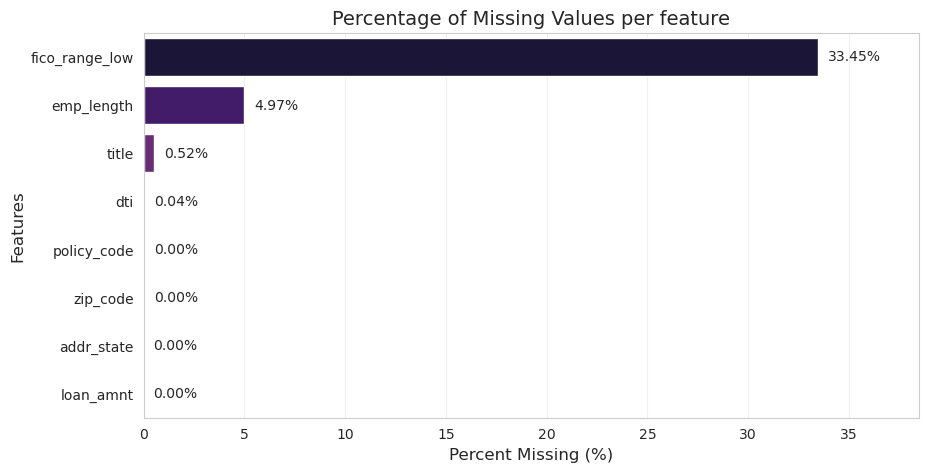

In [9]:
print(f"Calculating missing values...")
missing_counts = df_balanced.isna().sum()
missing_percent = (missing_counts / len(df_balanced)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(f"Columns with missing data: {len(missing_percent)}")
# visualize missing values
if len(missing_percent) > 0:
    plt.figure(figsize=(10,5))
    # use barplot for readability
    sns.barplot(
        x=missing_percent.values,
        y=missing_percent.index,
        palette='magma', 
        hue=missing_percent.index,
        legend=False
    )

    plt.title('Percentage of Missing Values per feature', fontsize=14)
    plt.xlabel('Percent Missing (%)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.xlim(0, max(missing_percent.values) + 5)
    plt.grid(axis='x', alpha=0.3)
    # add exact % test to end of each bar
    for index, value in enumerate(missing_percent.values):
        plt.text(value + 0.5, index, f'{value:.2f}%', va='center')

    plt.show()
else:
    print(f"No missing values found!")

In [10]:
print("--- Missing 'fico_range_low' Breakdown ---")
# Calculate how many NaNs are in each class (0 = Rejected, 1 = Accepted)
missing_by_class = df_balanced.groupby('is_accepted')['fico_range_low'].apply(lambda x: x.isna().sum())
total_by_class = df_balanced.groupby('is_accepted').size()
# Print the results
for class_label in [1, 0]:
    status = "Accepted" if class_label == 1 else "Rejected"
    missing = missing_by_class[class_label]
    total = total_by_class[class_label]
    pct = (missing / total) * 100
    
    print(f"{status} (Class {class_label}):")
    print(f"   -> {missing:,} missing out of {total:,} ({pct:.2f}%)")

--- Missing 'fico_range_low' Breakdown ---
Accepted (Class 1):
   -> 33 missing out of 2,260,701 (0.00%)
Rejected (Class 0):
   -> 1,512,233 missing out of 2,260,701 (66.89%)


In [11]:
print(f"--- Starting Feature Cleaning ----")
# clean emp_length (converison to numeric), "1< year" --> 0 and "10+ years" ---> 10
emp_map = {
    '< 1 year': 0.0,
    '1 year': 1.0,
    '2 years': 2.0,
    '3 years': 3.0,
    '4 years': 4.0,
    '5 years': 5.0,
    '6 years': 6.0,
    '7 years': 7.0,
    '8 years': 8.0,
    '9 years': 9.0,
    '10+ years': 10.0
}
df_balanced['emp_length'] = df_balanced['emp_length'].map(emp_map)

# clean 'zip_code' (conversion to numerci)
unique_zips = df_balanced['zip_code'].dropna().unique()
zip_map = {z: float(str(z).replace('xx', '')) for z in unique_zips}
df_balanced['zip_code'] = df_balanced['zip_code'].map(zip_map)

# clean 'addr_state' & 'policy_code'
df_balanced['title'] = df_balanced['title'].fillna('Unknown').astype('category')
df_balanced['addr_state'] = df_balanced['addr_state'].fillna('Unknown').astype(str).astype('category')

print(f"---- Feature Cleaning Complete ----")
print(df_balanced[['emp_length', 'zip_code', 'title']].head())
print(f"\nData Types:")
print(df_balanced.dtypes)

--- Starting Feature Cleaning ----
---- Feature Cleaning Complete ----
   emp_length  zip_code                    title
0         2.0     756.0       Debt consolidation
1         0.0     293.0              credit_card
2        10.0     329.0  Credit card refinancing
3         0.0     336.0       Debt consolidation
4         0.0     242.0       debt_consolidation

Data Types:
loan_amnt          float64
emp_length         float64
title             category
zip_code           float64
addr_state        category
dti                float64
fico_range_low     float64
policy_code        float64
is_accepted          int64
dtype: object


In [12]:
df_balanced.head()

,loan_amnt,emp_length,title,zip_code,addr_state,dti,fico_range_low,policy_code,is_accepted
0,8000.0,2.0,Debt consolidation,756.0,TX,9.72,665.0,1.0,1
1,7500.0,0.0,credit_card,293.0,SC,32.33,662.0,0.0,0
2,12825.0,10.0,Credit card refinancing,329.0,FL,27.55,715.0,1.0,1
3,10000.0,0.0,Debt consolidation,336.0,FL,20.40,NaN,0.0,0
4,5000.0,0.0,debt_consolidation,242.0,VA,7.38,NaN,0.0,0


In [13]:
print(f"---- Inspecting Title Column -----")
# total count of unique values
unique_titles = df_balanced['title'].cat.categories
print(f"Total Unique titles: {len(unique_titles):,}\n")
# look at top 50 most common titles
top_50 = df_balanced['title'].value_counts().head(50)
print(f"Top 50 Most Common Titles:")
print(top_50)

print(f"----- Checking top 50 title coverage ------")
title_counts = df_balanced['title'].value_counts()
top_50_total_rows = title_counts.head(50).sum()
total_rows = len(df_balanced)
coverage_percent = (top_50_total_rows / total_rows) * 100
print(f"Top 50 titles cover {top_50_total_rows:,} out of {total_rows:,} rows.")
print(f"Coverage Percentage: {coverage_percent:.2f}%")

---- Inspecting Title Column -----
Total Unique titles: 68,615

Top 50 Most Common Titles:
title
Debt consolidation           1677983
Credit card refinancing       657509
debt_consolidation            482432
Other                         344776
Home improvement              175846
other                         167331
credit_card                   111302
Major purchase                 84887
Car financing                  83010
home_improvement               58618
Medical expenses               57464
Home buying                    53132
car                            42996
Moving and relocation          40037
major_purchase                 38605
Business                       38319
moving                         31155
medical                        29223
Business Loan                  27680
Vacation                       25599
small_business                 25373
Unknown                        23460
Debt Consolidation             16228
house                          14891
vacation       

In [14]:
print(f"------ Standardizing the top 50 Titles -----")
# define explicit mapping dicitonary, group the top 50 into 12 clean buckets 
title_map = {
    # Debt Consolidation Bucket
    'Debt consolidation': 'debt_consolidation',
    'debt_consolidation': 'debt_consolidation',
    'Debt Consolidation': 'debt_consolidation',
    'debt consolidation': 'debt_consolidation',
    'Debt Consolidation Loan': 'debt_consolidation',
    'Consolidation': 'debt_consolidation',
    'consolidation': 'debt_consolidation',
    'Consolidation Loan': 'debt_consolidation',
    'Consolidate': 'debt_consolidation',
    'consolidate': 'debt_consolidation',
    'Debt': 'debt_consolidation',
    'Payoff': 'debt_consolidation',
    # Credit Card Bucket
    'Credit card refinancing': 'credit_card',
    'credit_card': 'credit_card',
    'Credit Card Consolidation': 'credit_card',
    'Credit Card Refinance': 'credit_card',
    'Credit Card Payoff': 'credit_card',
    'Credit Card Loan': 'credit_card',
    # Home & Housing Bucket
    'Home improvement': 'home_improvement',
    'home_improvement': 'home_improvement',
    'Home buying': 'home_improvement',
    'house': 'home_improvement',
    'Home Improvement': 'home_improvement',
    'home improvement': 'home_improvement',
    # Vehicles Bucket
    'Car financing': 'car',
    'car': 'car',
    # Major Purchase Bucket
    'Major purchase': 'major_purchase',
    'major_purchase': 'major_purchase',
    # Medical Bucket
    'Medical expenses': 'medical',
    'medical': 'medical',
    # Moving Bucket
    'Moving and relocation': 'moving',
    'moving': 'moving',
    # Business Bucket
    'Business': 'business',
    'Business Loan': 'business',
    'small_business': 'business',
    # Vacation Bucket
    'Vacation': 'vacation',
    'vacation': 'vacation',
    # Green/Renewable Bucket
    'Green loan': 'green_loan',
    'renewable_energy': 'green_loan',
    # Wedding Bucket
    'wedding': 'wedding',
    # Generic / Personal / Other Bucket
    'Other': 'other',
    'other': 'other',
    'Unknown': 'other',
    'Personal Loan': 'other',
    'Personal': 'other',
    'Loan': 'other',
    'personal': 'other',
    'personal loan': 'other',
    'Freedom': 'other',
    ' ': 'other'  # Blank spaces
}
# map the titles and push everything else (the 3.3% long tail) into 'other'
df_balanced['title'] = df_balanced['title'].map(title_map)
df_balanced['title'] = df_balanced['title'].fillna('other').astype('category')
print(f"------ Title Clean-up Complete ------")
print(f"New cleaned title distirbuiton.")
print(df_balanced['title'].value_counts())
if df_balanced['title'].value_counts().sum() == len(df_balanced):
    print(f"All title data inputs are normalized and ready for training")
else:
    print(f"Some values remain that are not part of the 12 standard mappings")

------ Standardizing the top 50 Titles -----
------ Title Clean-up Complete ------
New cleaned title distirbuiton.
title
debt_consolidation    2198780
credit_card            774968
other                  696451
home_improvement       305085
car                    126006
major_purchase         123492
business                91372
medical                 86687
moving                  71192
vacation                39969
green_loan               5794
wedding                  1606
Name: count, dtype: int64
All title data inputs are normalized and ready for training


In [15]:
# drop policy code, data leak that gives model answer key
# drop fico_range_low, a post-decision artificat
from sklearn.model_selection import train_test_split
print(f"------ Splitting Data for training & testing -----")
# define features (X) and (y)
X = df_balanced.drop(columns=[
    'is_accepted', 
    'policy_code', 
    'fico_range_low',
    'emp_length'
    #'title'
])
y = df_balanced['is_accepted']
# standard 80/20 split to create train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, 
    random_state=42,
    stratify=y
)
print(f"Training Data: {X_train.shape[0]:,} rows")
print(f"Testing Data: {X_test.shape[0]:,} rows")
print(f"Applicant Provided Data: \n{list(X_train.columns)}")

------ Splitting Data for training & testing -----
Training Data: 3,617,121 rows
Testing Data: 904,281 rows
Applicant Provided Data: 
['loan_amnt', 'title', 'zip_code', 'addr_state', 'dti']


In [16]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, ParameterSampler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import warnings

warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
n_iter = 10
params_list = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))
best_score = 0
best_params = None
print(f"---- Starting Hyperparameter tuning ({n_iter} runs) ----")
# manual cross-validation loop
for i, params in enumerate(params_list):
    fold_scores = []
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(X_train, y_train):
        # split data using pandas .iloc
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        # initialize model
        model = xgb.XGBClassifier(
            **params,
            enable_categorical=True,
            objective='binary:logistic',
            eval_metric='auc',
            device='cuda',
            tree_method='hist',
            verbosity=0,
            n_jobs=1,
            random_state=42
        )
        # train & evaluate
        model.fit(X_fold_train, y_fold_train, verbose=False)
        # score using AUC (area under ROC curve)
        preds = model.predict_proba(X_fold_val)[:, 1]
        score = roc_auc_score(y_fold_val, preds)
        fold_scores.append(score)
    # avg the scores across 5 folds
    avg_score = np.mean(fold_scores)
    print(f"Iter {i+1:02d}/{n_iter} | 5-fold Avg AUC: {avg_score:.4f} | Params: {params}")
    if avg_score > best_score:
        best_score = avg_score
        best_params = params
print(f"\n Winner found! Best 5-Fold AUC: {best_score:.4f}")

# final testing on the full dataset
print(f"\n---- Training Final Gatekeeper Model -----")
best_gatekeeper = xgb.XGBClassifier(
    **best_params,
    enable_categorical=True,
    objective='binary:logistic',
    eval_metric='auc',
    device='cuda',
    tree_method='hist',
    n_jobs=1,
    random_state=42
)
best_gatekeeper.fit(X_train, y_train)

# final evaluation on unseen data
print(f"\n--- Final Model Performance (Test Set) ----")
y_pred = best_gatekeeper.predict(X_test)
# confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"True Negatives (Correctly Rejected junk): {tn:,}")
print(f"False Positives (Junk accidentally accepted): {fp:,}")
print(f"False Negatives (Good Customers blocked): {fn:,}")
print(f"True Positives (Good customers accepted): {tp:,}")

print(f"\nFull classification report:")
print(classification_report(y_test, y_pred))

---- Starting Hyperparameter tuning (10 runs) ----
Iter 01/10 | 5-fold Avg AUC: 0.8393 | Params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Iter 02/10 | 5-fold Avg AUC: 0.8283 | Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Iter 03/10 | 5-fold Avg AUC: 0.8047 | Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Iter 04/10 | 5-fold Avg AUC: 0.8458 | Params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Iter 05/10 | 5-fold Avg AUC: 0.8171 | Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Iter 06/10 | 5-fold Avg AUC: 0.8183 | Params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Iter 07/10 | 5-fold Avg AUC: 0.8428 | Params: {'s

--- Diagnosing the AUC (Feature Importances) ---


<Figure size 1000x600 with 0 Axes>

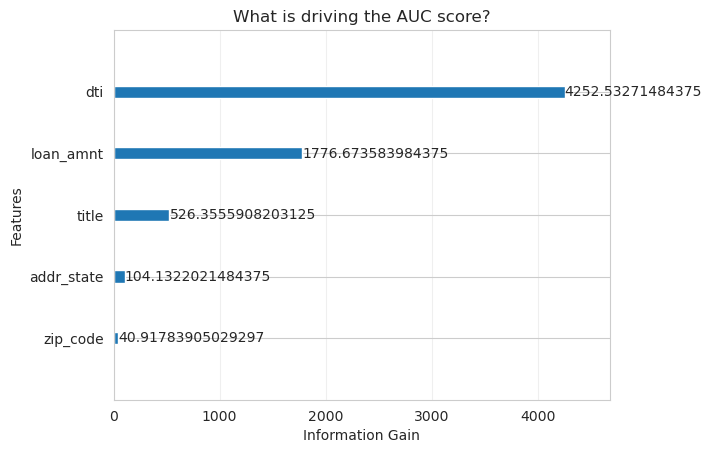

In [17]:
print("--- Diagnosing the AUC (Feature Importances) ---")
# 'gain' shows how much accuracy the model gained by splitting on a feature
plt.figure(figsize=(10, 6))
xgb.plot_importance(
    best_gatekeeper, 
    importance_type='gain', 
    max_num_features=10, 
    title='What is driving the AUC score?', 
    xlabel='Information Gain'
)
plt.grid(axis='x', alpha=0.3)
plt.show()
# 'emp_length' had a gain score of 20,000! This is a leak that is skewing the model's results, it must be dropped before reaching this step...

In [18]:
# save the best gatekeeper model
import json
import os

folder_path = 'Models'
os.makedirs(folder_path, exist_ok=True)

gatekeeper_model_path = os.path.join(folder_path, 'best_gatekeeper_model.json')
gatekeeper_features_path = os.path.join(folder_path, 'gatekeeper_features.json')

best_gatekeeper.save_model(gatekeeper_model_path)
print(f"Gatekeeper model saved successfully to: {gatekeeper_model_path}")
gatekeeper_feature_list = X_train.columns.tolist()

with open(gatekeeper_features_path, "w") as f:
    json.dump(gatekeeper_features_path, f)

print(f"Gatekeeper Features ({len(gatekeeper_feature_list)}) saved to: {gatekeeper_features_path}")

Gatekeeper model saved successfully to: Models/best_gatekeeper_model.json
Gatekeeper Features (5) saved to: Models/gatekeeper_features.json


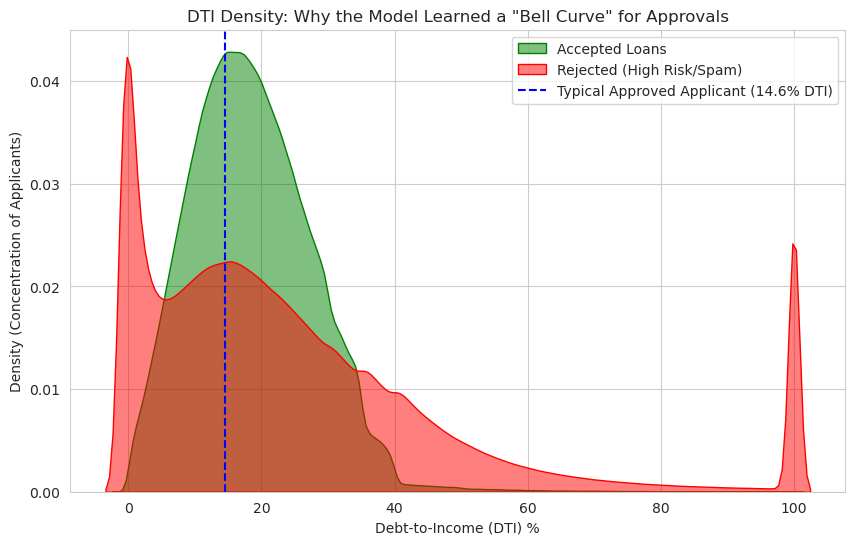

In [20]:
# Generate the most impactful visual for recruiters: The Logic Check
plt.figure(figsize=(10, 6))
sns.kdeplot(df_zoom[df_zoom['is_accepted'] == 1]['dti'], label='Accepted Loans', fill=True, color='green', alpha=0.5)
sns.kdeplot(df_zoom[df_zoom['is_accepted'] == 0]['dti'], label='Rejected (High Risk/Spam)', fill=True, color='red', alpha=0.5)

plt.title('DTI Density: Why the Model Learned a "Bell Curve" for Approvals')
plt.xlabel('Debt-to-Income (DTI) %')
plt.ylabel('Density (Concentration of Applicants)')
plt.axvline(x=14.6, color='blue', linestyle='--', label='Typical Approved Applicant (14.6% DTI)')
plt.legend()
plt.savefig('dti_logic_visual.png')
plt.show()